In [1]:
import numpy as np
import pandas as pd
import time as time

In [2]:
df=pd.read_csv('Social_Network_Ads.xls')

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.drop('User ID',axis=1,inplace=True)

In [5]:
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaling=StandardScaler()
X_scaled=scaling.fit_transform(X)

In [8]:
X_scaled.shape

(400, 2)

In [9]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [10]:
model = Sequential()

model.add(Input(shape=(X_scaled.shape[1],)))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(loss=['binary_crossentropy'],metrics=['accuracy'])
history=model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9125 - loss: 0.2252 - val_accuracy: 0.9625 - val_loss: 0.2070
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9062 - loss: 0.2277 - val_accuracy: 0.9625 - val_loss: 0.1845
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9125 - loss: 0.2376 - val_accuracy: 0.9625 - val_loss: 0.1762
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9125 - loss: 0.2429 - val_accuracy: 0.9625 - val_loss: 0.1815
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9125 - loss: 0.2426 - val_accuracy: 0.9625 - val_loss: 0.1710
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9031 - loss: 0.2554 - val_accuracy: 0.9625 - val_loss: 0.1686
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9094 - loss: 0.2437 - val_accuracy: 0.9625 - val_loss: 0.1643
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9062 - loss: 0.2544 - val_accu

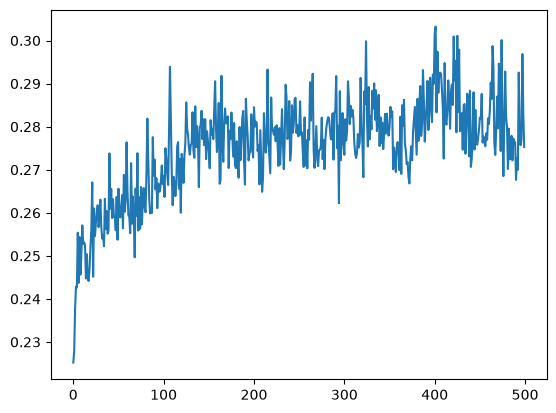

In [38]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [39]:
history = model.fit(X_scaled,y,epochs=500,batch_size=100,validation_split=0.2)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.9094 - loss: 0.2715 - val_accuracy: 0.9375 - val_loss: 0.2210
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9094 - loss: 0.2675 - val_accuracy: 0.9375 - val_loss: 0.2259
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9094 - loss: 0.2634 - val_accuracy: 0.9375 - val_loss: 0.2304
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9094 - loss: 0.2602 - val_accuracy: 0.9375 - val_loss: 0.2344
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9094 - loss: 0.2567 - val_accuracy: 0.9375 - val_loss: 0.2323
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9062 - loss: 0.2541 - val_accuracy: 0.9250 - val_loss: 0.2397
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9062 - loss: 0.2499 - val_accuracy: 0.9250 - val_loss: 0.2407
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9062 - loss: 0.2480 - val_accuracy: 0.9250 - val_loss

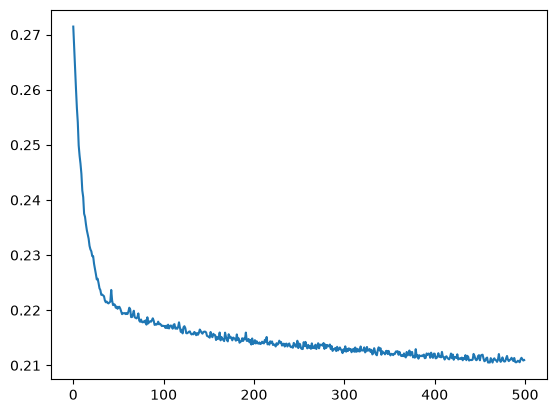

In [40]:
plt.plot(history.history['loss'])

In [41]:
history = model.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9187 - loss: 0.2104 - val_accuracy: 0.9250 - val_loss: 0.2887
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9187 - loss: 0.2101 - val_accuracy: 0.9250 - val_loss: 0.2882
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9187 - loss: 0.2100 - val_accuracy: 0.9250 - val_loss: 0.2877
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9187 - loss: 0.2100 - val_accuracy: 0.9250 - val_loss: 0.2873
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9187 - loss: 0.2099 - val_accuracy: 0.9250 - val_loss: 0.2855
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9187 - loss: 0.2099 - val_accuracy: 0.9250 - val_loss: 0.2853
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9187 - loss: 0.2099 - val_accuracy: 0.9250 - val_loss: 0.2851
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9187 - loss: 0.2099 - val_accuracy: 0.9250 - v

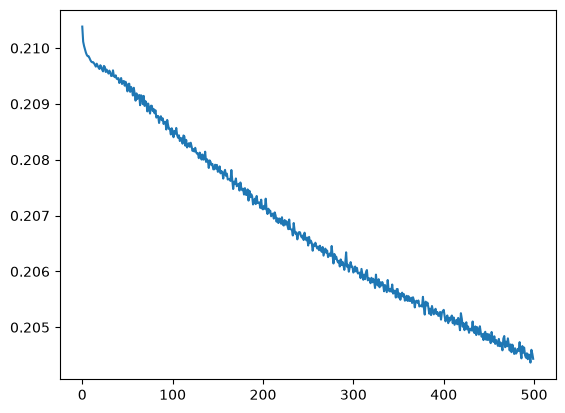

In [42]:
plt.plot(history.history['loss'])